# Диагностические кривые

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, auc, classification_report
from numpy import argmax

In [2]:
X, y = make_classification(n_samples=1000, n_classes=2, random_state=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=2)

In [3]:
model = LogisticRegression().fit(X_train, y_train)
y_pred_proba = model.predict_proba(X_test)   # матрица [P(0), P(1)]

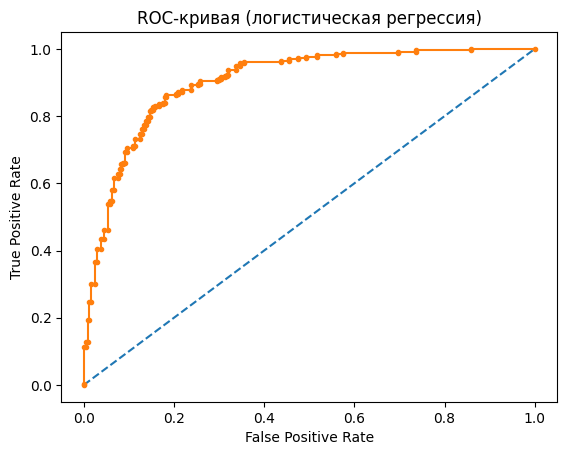

In [4]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba[:, 1])
plt.plot([0, 1], [0, 1], linestyle='--')
plt.plot(fpr, tpr, marker='.')
plt.title('ROC-кривая (логистическая регрессия)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

In [5]:
roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])
print(f'ROC-AUC = {roc_auc:.3f}')

ROC-AUC = 0.903


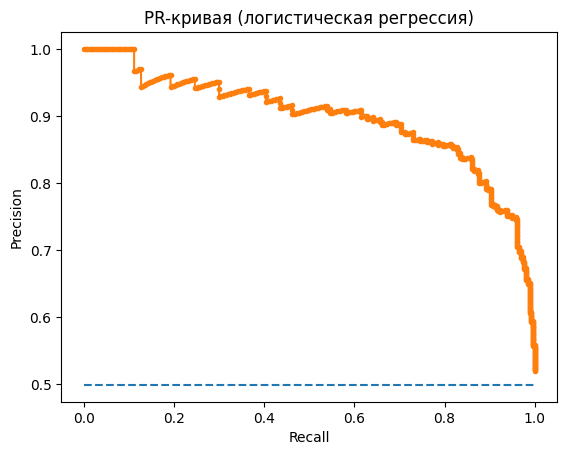

PR-AUC = 0.898


In [6]:
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba[:, 1])
no_skill = len(y[y==1]) / len(y)   # baseline для несбалансированных данных
plt.plot([0, 1], [no_skill, no_skill], linestyle='--')
plt.plot(recall, precision, marker='.')
plt.title('PR-кривая (логистическая регрессия)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()

pr_auc = auc(recall, precision)
print(f'PR-AUC = {pr_auc:.3f}')

In [7]:
y_pred_default = model.predict(X_test)
print(classification_report(y_test, y_pred_default))

              precision    recall  f1-score   support

           0       0.83      0.82      0.83       240
           1       0.84      0.85      0.84       260

    accuracy                           0.83       500
   macro avg       0.83      0.83      0.83       500
weighted avg       0.83      0.83      0.83       500



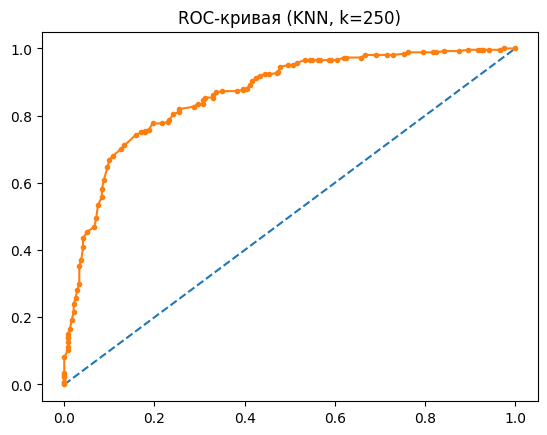

ROC-AUC для KNN = 0.863


In [8]:
model2 = KNeighborsClassifier(n_neighbors=250).fit(X_train, y_train)
y_pred2_proba = model2.predict_proba(X_test)

fpr2, tpr2, _ = roc_curve(y_test, y_pred2_proba[:, 1])
plt.plot([0, 1], [0, 1], linestyle='--')
plt.plot(fpr2, tpr2, marker='.')
plt.title('ROC-кривая (KNN, k=250)')
plt.show()

roc_auc2 = roc_auc_score(y_test, y_pred2_proba[:, 1])
print(f'ROC-AUC для KNN = {roc_auc2:.3f}')

In [9]:
X, y = make_classification(n_samples=1000, n_classes=2, weights=[0.99, 0.01], random_state=1)
print('Распределение в полном датасете:')
print(f'Class0 = {len(y[y==0])}, Class1 = {len(y[y==1])}')

Распределение в полном датасете:
Class0 = 985, Class1 = 15


In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, stratify=y, random_state=4)
print('Обучающая выборка:', np.bincount(y_train))
print('Тестовая выборка:', np.bincount(y_test))

Обучающая выборка: [492   8]
Тестовая выборка: [493   7]


In [11]:
model_imb = LogisticRegression().fit(X_train, y_train)
y_pred_imb_proba = model_imb.predict_proba(X_test)

In [12]:
y_pred_imb_default = model_imb.predict(X_test)
print(classification_report(y_test, y_pred_imb_default))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       493
           1       1.00      0.14      0.25         7

    accuracy                           0.99       500
   macro avg       0.99      0.57      0.62       500
weighted avg       0.99      0.99      0.98       500



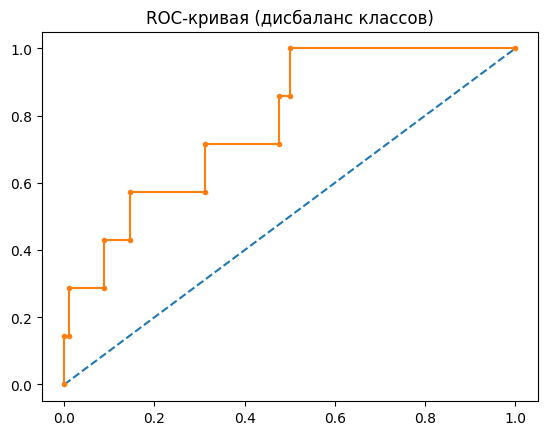

In [13]:
fpr_imb, tpr_imb, _ = roc_curve(y_test, y_pred_imb_proba[:, 1])
plt.plot([0, 1], [0, 1], linestyle='--')
plt.plot(fpr_imb, tpr_imb, marker='.')
plt.title('ROC-кривая (дисбаланс классов)')
plt.show()

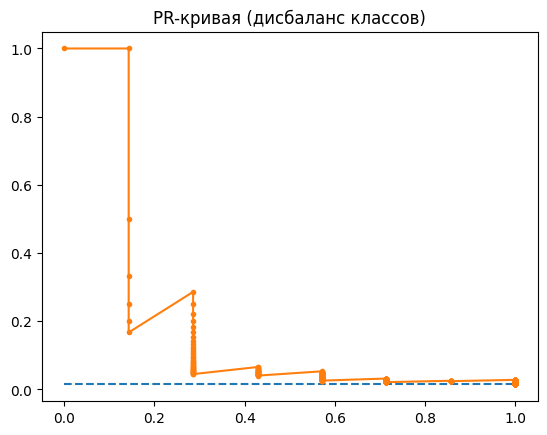

In [14]:
prec_imb, rec_imb, _ = precision_recall_curve(y_test, y_pred_imb_proba[:, 1])
no_skill_imb = len(y[y==1]) / len(y)
plt.plot([0, 1], [no_skill_imb, no_skill_imb], linestyle='--')
plt.plot(rec_imb, prec_imb, marker='.')
plt.title('PR-кривая (дисбаланс классов)')
plt.show()

In [15]:
# Для надёжности генерируем ещё один датасет с большим количеством объектов (10000)
X2, y2 = make_classification(n_samples=10000, n_classes=2, weights=[0.99, 0.01], random_state=1)
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.5, stratify=y2, random_state=1)

model_opt = LogisticRegression().fit(X_train2, y_train2)
y_proba_opt = model_opt.predict_proba(X_test2)

# Получаем precision, recall и пороги из PR-кривой
p_opt, r_opt, thresholds_opt = precision_recall_curve(y_test2, y_proba_opt[:, 1])
# Вычисляем F1 для каждого порога (кроме последнего, т.к. thresholds_opt на один элемент короче)
f1_opt = (2 * p_opt[:-1] * r_opt[:-1]) / (p_opt[:-1] + r_opt[:-1] + 1e-9)
ix_opt = argmax(f1_opt)
best_thresh = thresholds_opt[ix_opt]
print(f'Оптимальный порог = {best_thresh:.6f}')
print(f'Максимальный F1 = {f1_opt[ix_opt]:.3f}')

Оптимальный порог = 0.120462
Максимальный F1 = 0.428


In [16]:
# Предсказания с порогом 0.5 (по умолчанию)
y_pred_default_opt = (y_proba_opt[:, 1] >= 0.5).astype(int)
# Предсказания с оптимальным порогом
y_pred_best = (y_proba_opt[:, 1] >= best_thresh).astype(int)

print("=== Отчёт для порога 0.5 ===")
print(classification_report(y_test2, y_pred_default_opt))
print("\n=== Отчёт для оптимального порога ===")
print(classification_report(y_test2, y_pred_best))

=== Отчёт для порога 0.5 ===
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      4920
           1       0.83      0.12      0.22        80

    accuracy                           0.99      5000
   macro avg       0.91      0.56      0.61      5000
weighted avg       0.98      0.99      0.98      5000


=== Отчёт для оптимального порога ===
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4920
           1       0.43      0.42      0.43        80

    accuracy                           0.98      5000
   macro avg       0.71      0.71      0.71      5000
weighted avg       0.98      0.98      0.98      5000



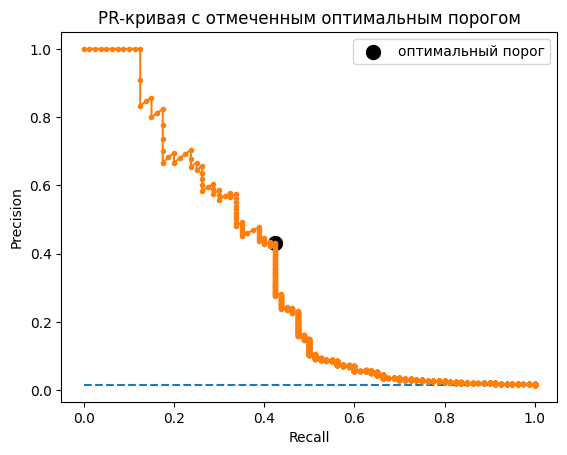

In [17]:
plt.plot([0, 1], [no_skill_imb, no_skill_imb], linestyle='--')
plt.plot(r_opt, p_opt, marker='.')
plt.scatter(r_opt[ix_opt], p_opt[ix_opt], marker='o', color='black', s=100, label='оптимальный порог')
plt.title('PR-кривая с отмеченным оптимальным порогом')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.show()

# Задание для самостоятельного решения

## Пункт 1: 2D-датасет — влияние порога на границу принятия решений

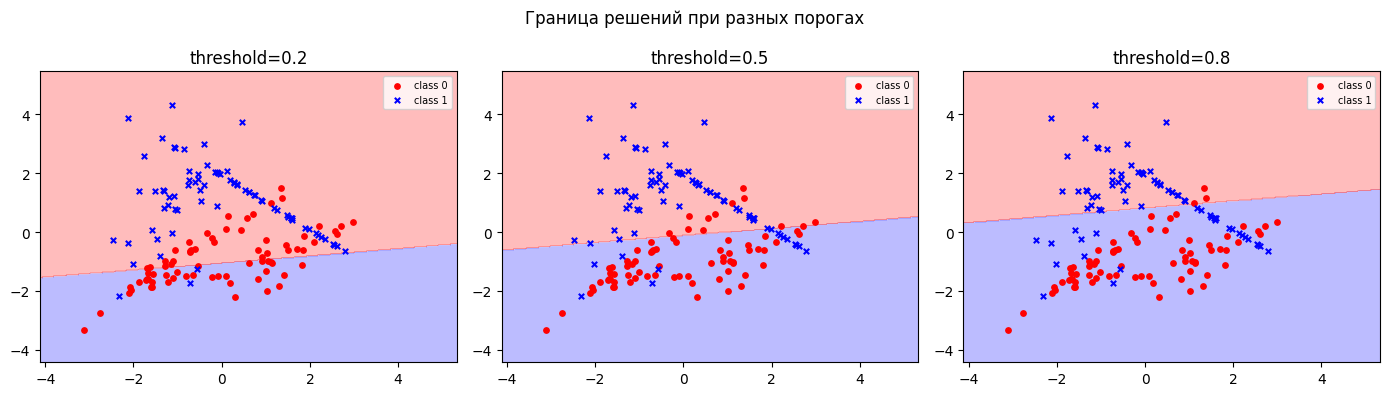

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, precision_recall_curve, auc, roc_auc_score

# 2D датасет с двумя признаками
X2d, y2d = make_classification(n_samples=500, n_features=2, n_informative=2,
                                n_redundant=0, class_sep=1.0, random_state=0)
Xtr, Xte, ytr, yte = train_test_split(X2d, y2d, test_size=0.3, random_state=0)

m2d = LogisticRegression().fit(Xtr, ytr)
proba2d = m2d.predict_proba(Xte)[:, 1]

# Сетка для отрисовки границы
xx, yy = np.meshgrid(np.linspace(X2d[:,0].min()-1, X2d[:,0].max()+1, 300),
                      np.linspace(X2d[:,1].min()-1, X2d[:,1].max()+1, 300))
grid_proba = m2d.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)

thresholds_vis = [0.2, 0.5, 0.8]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, thr in zip(axes, thresholds_vis):
    Z = (grid_proba >= thr).astype(int)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
    ax.scatter(Xte[:,0][yte==0], Xte[:,1][yte==0], c='r', s=15, label='class 0')
    ax.scatter(Xte[:,0][yte==1], Xte[:,1][yte==1], c='b', marker='x', s=15, label='class 1')
    ax.set_title(f"threshold={thr}")
    ax.legend(fontsize=7)

plt.suptitle("Граница решений при разных порогах")
plt.tight_layout(); plt.show()
# Вывод: чем ниже порог — тем «агрессивнее» модель относит точки к классу 1

## Пункт 2: ROC и PR на реальном датасете — Breast Cancer

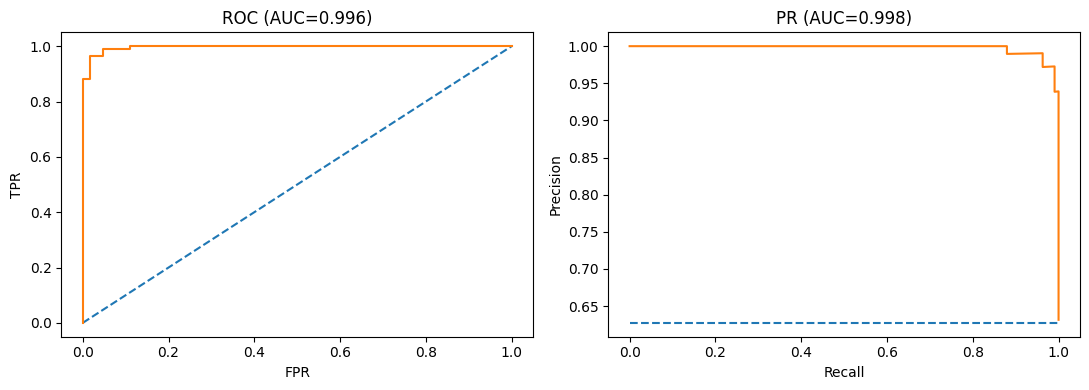

              precision    recall  f1-score   support

   malignant       0.91      0.98      0.95        63
      benign       0.99      0.94      0.97       108

    accuracy                           0.96       171
   macro avg       0.95      0.96      0.96       171
weighted avg       0.96      0.96      0.96       171



In [19]:
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import classification_report
import pandas as pd

bc = load_breast_cancer()
Xbc, ybc = bc.data, bc.target
Xbc_tr, Xbc_te, ybc_tr, ybc_te = train_test_split(Xbc, ybc, test_size=0.3, random_state=0)

mbc = LogisticRegression(max_iter=5000).fit(Xbc_tr, ybc_tr)
proba_bc = mbc.predict_proba(Xbc_te)[:, 1]

# ROC
fpr_bc, tpr_bc, thr_roc = roc_curve(ybc_te, proba_bc)
roc_bc = roc_auc_score(ybc_te, proba_bc)

# PR
p_bc, r_bc, thr_pr = precision_recall_curve(ybc_te, proba_bc)
pr_bc = auc(r_bc, p_bc)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot([0,1],[0,1],'--'); axes[0].plot(fpr_bc, tpr_bc)
axes[0].set_title(f"ROC (AUC={roc_bc:.3f})"); axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")

no_skill = ybc.mean()
axes[1].plot([0,1],[no_skill,no_skill],'--'); axes[1].plot(r_bc, p_bc)
axes[1].set_title(f"PR (AUC={pr_bc:.3f})"); axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
plt.tight_layout(); plt.show()

print(classification_report(ybc_te, mbc.predict(Xbc_te), target_names=bc.target_names))
# Интерпретация: ROC-AUC>0.99 — отличная разделимость; PR-AUC высокий несмотря на slight imbalance

## Пункт 3: Оптимизация порога по ROC — критерий: максимум геометрического среднего TPR и (1-FPR)

Оптимальный порог по ROC (g-mean): 0.0189
TPR=0.637  FPR=0.172  G-mean=0.726


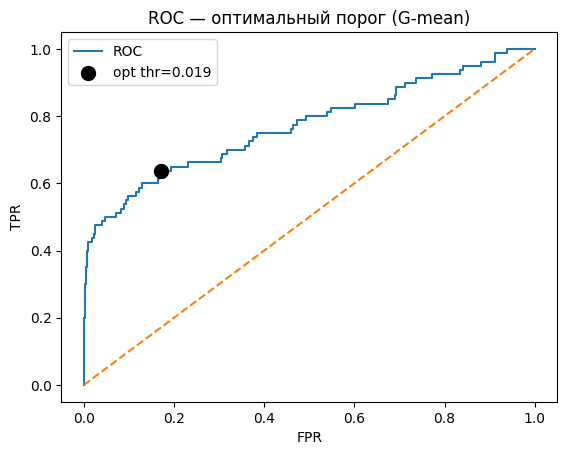

              precision    recall  f1-score   support

           0       0.99      0.83      0.90      4920
           1       0.06      0.64      0.10        80

    accuracy                           0.82      5000
   macro avg       0.52      0.73      0.50      5000
weighted avg       0.98      0.82      0.89      5000



In [20]:
# Используем датасет из методических указаний (X2, y2, model_opt, y_proba_opt уже определены выше)
fpr_r, tpr_r, thresholds_r = roc_curve(y_test2, y_proba_opt[:, 1])

# Геометрическое среднее между TPR и (1-FPR) — максимум = оптимальный баланс
gmean = np.sqrt(tpr_r * (1 - fpr_r))
ix_gm = np.argmax(gmean)
best_thresh_roc = thresholds_r[ix_gm]
print(f"Оптимальный порог по ROC (g-mean): {best_thresh_roc:.4f}")
print(f"TPR={tpr_r[ix_gm]:.3f}  FPR={fpr_r[ix_gm]:.3f}  G-mean={gmean[ix_gm]:.3f}")

plt.plot(fpr_r, tpr_r, label='ROC')
plt.plot([0,1],[0,1],'--')
plt.scatter(fpr_r[ix_gm], tpr_r[ix_gm], s=100, c='k', zorder=5, label=f'opt thr={best_thresh_roc:.3f}')
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC — оптимальный порог (G-mean)")
plt.legend(); plt.show()

y_pred_roc = (y_proba_opt[:, 1] >= best_thresh_roc).astype(int)
print(classification_report(y_test2, y_pred_roc))

## Пункт 4: PR-кривая — F_beta с преимуществом precision и recall

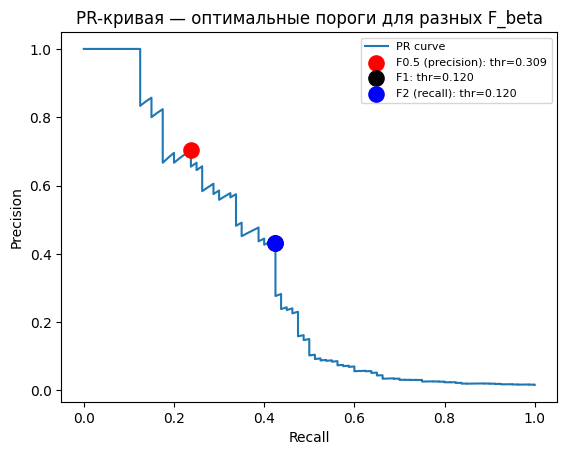


=== F0.5 (precision) (thr=0.3093) ===
precision=0.704  recall=0.237

=== F1 (thr=0.1205) ===
precision=0.430  recall=0.425

=== F2 (recall) (thr=0.1205) ===
precision=0.430  recall=0.425


In [21]:
from sklearn.metrics import fbeta_score

p_o, r_o, thr_o = precision_recall_curve(y_test2, y_proba_opt[:, 1])

# F_beta: beta<1 — важнее precision, beta>1 — важнее recall
results = {}
for beta, label in [(0.5, 'F0.5 (precision)'), (1.0, 'F1'), (2.0, 'F2 (recall)')]:
    # fbeta для каждого порога
    fb = ((1 + beta**2) * p_o[:-1] * r_o[:-1]) / (beta**2 * p_o[:-1] + r_o[:-1] + 1e-9)
    ix = np.argmax(fb)
    results[label] = {'thr': thr_o[ix], 'p': p_o[ix], 'r': r_o[ix], 'fb': fb[ix]}

# График PR с тремя порогами
plt.plot(r_o, p_o, label='PR curve')
colors = ['red', 'black', 'blue']
for (label, res), c in zip(results.items(), colors):
    plt.scatter(res['r'], res['p'], s=120, color=c, zorder=5,
                label=f"{label}: thr={res['thr']:.3f}")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("PR-кривая — оптимальные пороги для разных F_beta")
plt.legend(fontsize=8); plt.show()

# Метрики для каждого порога
for label, res in results.items():
    yp = (y_proba_opt[:, 1] >= res['thr']).astype(int)
    print(f"\n=== {label} (thr={res['thr']:.4f}) ===")
    print(f"precision={res['p']:.3f}  recall={res['r']:.3f}")

## Пункт 5: ROC и PR для задачи множественной классификации

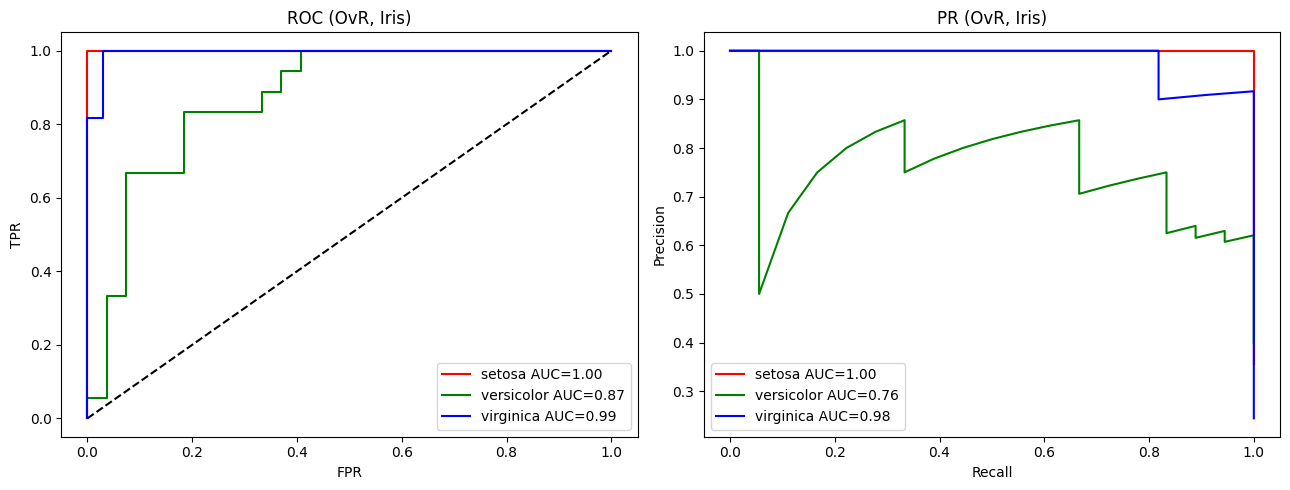

In [22]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_curve, auc

iris = load_iris()
X_ir, y_ir = iris.data, iris.target
# Бинаризуем метки (OvR)
y_ir_bin = label_binarize(y_ir, classes=[0, 1, 2])

Xir_tr, Xir_te, yir_tr, yir_te = train_test_split(X_ir, y_ir_bin, test_size=0.3, random_state=0)

# OvR логистическая регрессия
clf_ovr = OneVsRestClassifier(LogisticRegression(max_iter=1000)).fit(Xir_tr, yir_tr)
yir_proba = clf_ovr.predict_proba(Xir_te)

# ROC для каждого класса
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['red', 'green', 'blue']
for i, (cls, c) in enumerate(zip(iris.target_names, colors)):
    fpr_i, tpr_i, _ = roc_curve(yir_te[:, i], yir_proba[:, i])
    auc_i = auc(fpr_i, tpr_i)
    axes[0].plot(fpr_i, tpr_i, c=c, label=f"{cls} AUC={auc_i:.2f}")

axes[0].plot([0,1],[0,1],'k--')
axes[0].set_title("ROC (OvR, Iris)"); axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].legend()

# PR для каждого класса
for i, (cls, c) in enumerate(zip(iris.target_names, colors)):
    p_i, r_i, _ = precision_recall_curve(yir_te[:, i], yir_proba[:, i])
    axes[1].plot(r_i, p_i, c=c, label=f"{cls} AUC={auc(r_i,p_i):.2f}")

axes[1].set_title("PR (OvR, Iris)"); axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].legend()
plt.tight_layout(); plt.show()
# Интерпретация: setosa легко отделяется (AUC≈1.0);
# versicolor/virginica частично пересекаются — AUC ниже

## Пункт 6: Кривые с библиотекой yellowbrick

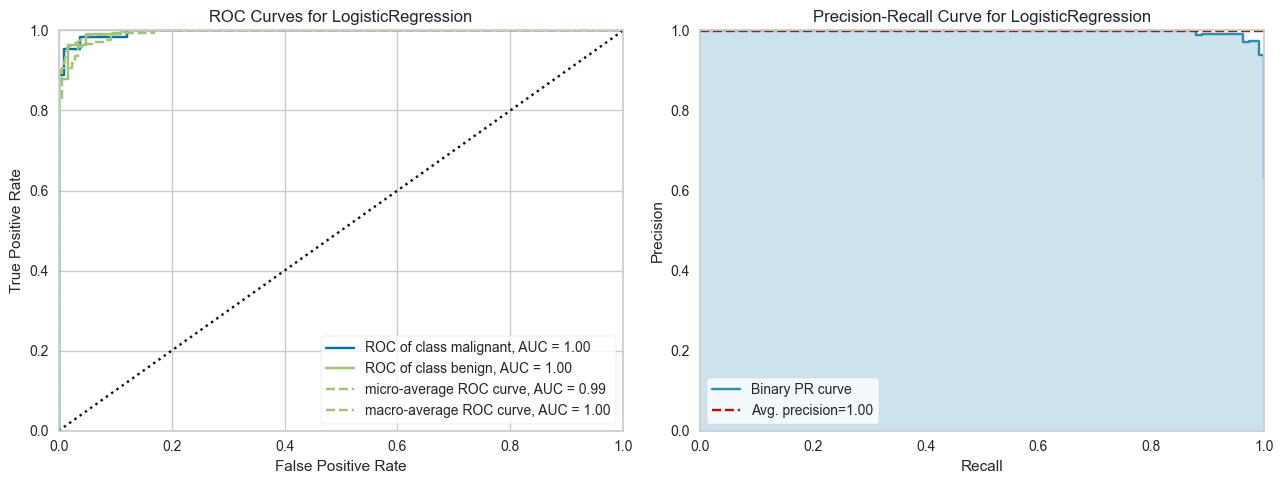

In [28]:
import matplotlib.pyplot as plt
from yellowbrick.classifier import ROCAUC, PrecisionRecallCurve
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

bc = load_breast_cancer()
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(bc.data, bc.target, test_size=0.3, random_state=0)

# ROC через yellowbrick
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
mbc2 = LogisticRegression(max_iter=5000)
viz_roc = ROCAUC(mbc2, classes=bc.target_names, ax=axes[0], force_model=True)  # ← добавили force_model
viz_roc.fit(Xb_tr, yb_tr)
viz_roc.score(Xb_te, yb_te)
viz_roc.finalize()

# PR через yellowbrick
mbc3 = LogisticRegression(max_iter=5000)
viz_pr = PrecisionRecallCurve(mbc3, classes=bc.target_names, ax=axes[1], force_model=True)  # ← и здесь
viz_pr.fit(Xb_tr, yb_tr)
viz_pr.score(Xb_te, yb_te)
viz_pr.finalize()

plt.tight_layout()
plt.show()